In [6]:
import numpy as np
from pathlib import Path

from model_ranking.datasets import get_datasets
from model_ranking.dataclass import EPFLTargetConfig

INFO: P [MainThread] 2025-06-10 16:44:43,711 plantseg - Logger configured at initialisation. PlantSeg logger name: plantseg


In [7]:
import re
def alphanum_key(s: str):
    # Split string into list of strings and integers for natural sorting
    return [int(text) if text.isdigit() else text.lower() for text in re.split('([0-9]+)', str(s))]

In [33]:
from numpy.typing import NDArray
from typing import Any, List
import matplotlib.pyplot as plt
def consis_score_histogram(
    scores: NDArray[Any], 
    consistency_threshold:float, 
    percentiles: List[float] = [60, 75, 90], 
    colors: List[str] = ['r', 'g', 'c']
    ) -> None:
    assert len(percentiles) == len(colors), (
        "percentiles and colors must both be None or both be lists of the same length"
    )
    _ = plt.figure(figsize=(10, 5))
    _ = plt.subplot(1, 2, 1)
    _ = plt.hist(scores, bins=50, weights=np.ones(len(scores)) / len(scores), alpha=0.7)
    for p, c in zip(percentiles, colors):
        perc = np.nanpercentile(scores, p)
        _ = plt.axvline(perc, linestyle='--', color=c, label=f'{p}th percentile ({perc:.2f})')

    # Plot the consistency threshold line
    _ = plt.axvline(
        consistency_threshold, 
        linestyle='--', 
        color='k', 
        label=f'% scores above CT ({np.sum(scores > consistency_threshold) / np.sum(~np.isnan(scores)):.3f})')

    plt.grid()
    _ = plt.title("patchwise consistency scores")
    _ = plt.xlabel('Consistency Scores')
    _ = plt.ylabel('frequency')
    _ = plt.legend()
    plt.show()

In [ ]:
base_dir_path ="/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3"
data_paths = Path(base_dir_path).glob("*.npz")
data_paths = sorted(data_paths, key=alphanum_key)

for data_path in data_paths:
    accepted_ids = np.load(data_path, allow_pickle=True)['accepted_ids']
    consis_scores = np.load(data_path, allow_pickle=True)['consis_scores']
    consis_score_histogram(consis_scores, consistency_threshold=0.9)

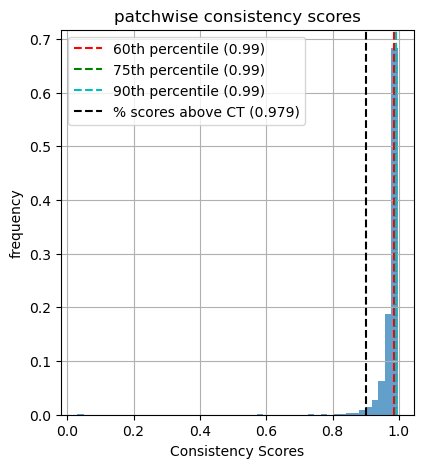

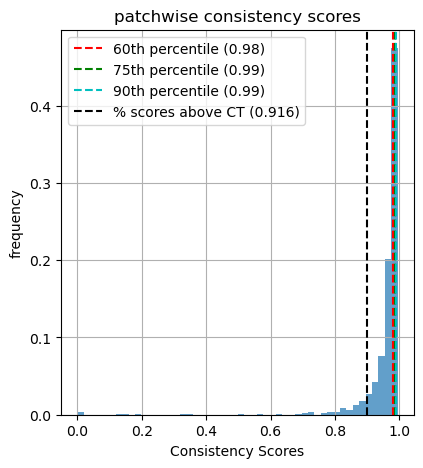

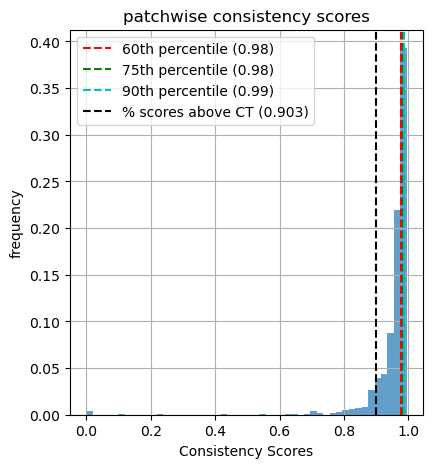

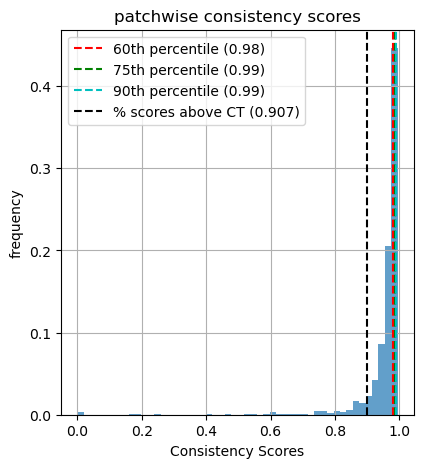

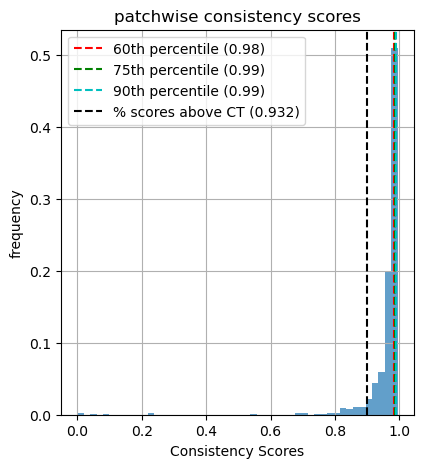

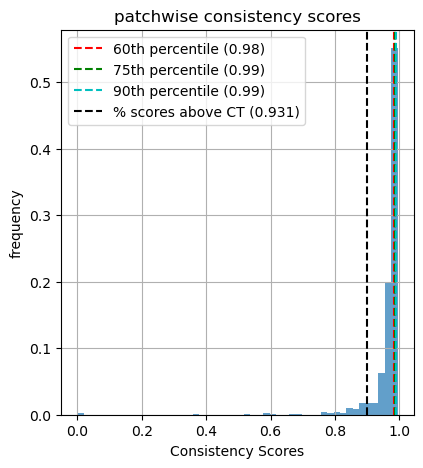

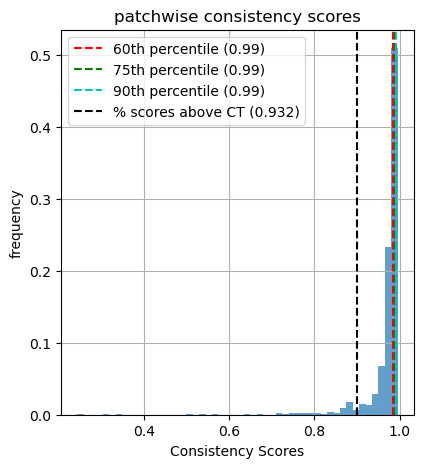

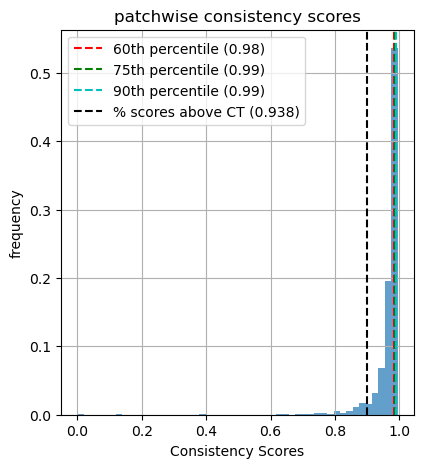

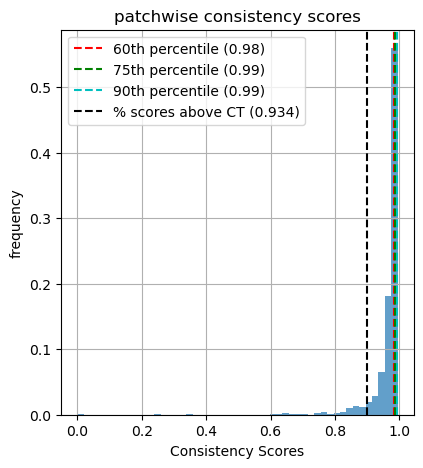

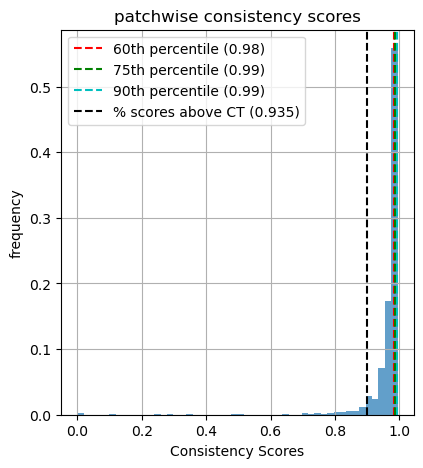

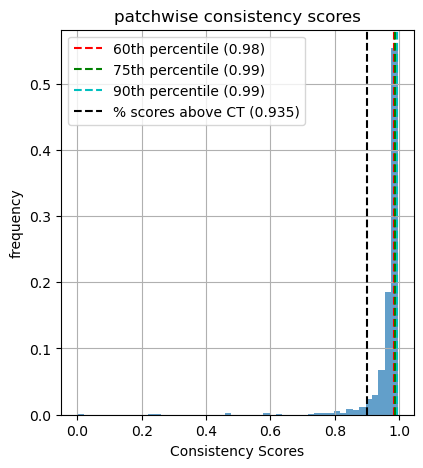

In [35]:
for data_path in data_paths:
    accepted_ids = np.load(data_path, allow_pickle=True)['accepted_ids']
    consis_scores = np.load(data_path, allow_pickle=True)['consis_scores']
    consis_score_histogram(consis_scores, consistency_threshold=0.9)

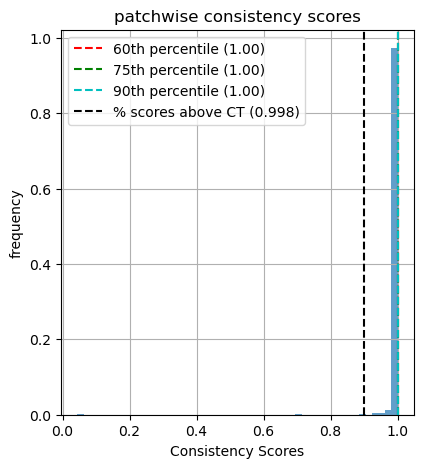

In [38]:
base_dir_path ="/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/09_consis_threshold_HD"
data_paths = Path(base_dir_path).glob("*.npz")
data_paths = sorted(data_paths, key=alphanum_key)

for data_path in data_paths:
    accepted_ids = np.load(data_path, allow_pickle=True)['accepted_ids']
    consis_scores = 1 - np.load(data_path, allow_pickle=True)['consis_scores']
    consis_score_histogram(consis_scores, consistency_threshold=0.9)

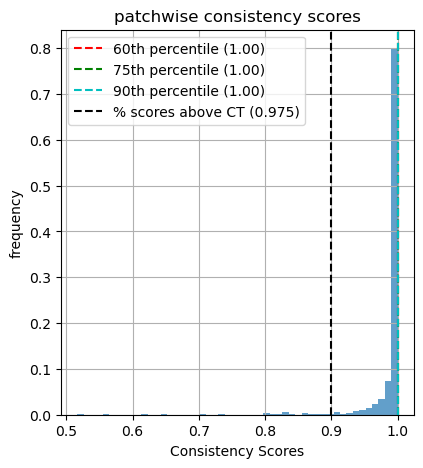

In [39]:
base_dir_path ="/g/kreshuk/talks/model_ranking_results/Self-Finetuning/Mitochondria/Hmito_to_EPFL_gap/feature_perturbation/pseudo_labeler/HtoE_DO_a02_model3/HD_DOa04"
data_paths = Path(base_dir_path).glob("*.npz")
data_paths = sorted(data_paths, key=alphanum_key)

for data_path in data_paths:
    accepted_ids = np.load(data_path, allow_pickle=True)['accepted_ids']
    consis_scores = 1 - np.load(data_path, allow_pickle=True)['consis_scores']
    consis_score_histogram(consis_scores, consistency_threshold=0.9)

In [40]:
np.nanmean(consis_scores)

0.9887055105600047

In [2]:
from model_ranking.utils import load_h5

path = "/g/kreshuk/talks/consistency_results/patch_segmentation/mitochondria/Hmito_to_EPFL_gap/feature_perturbation_consistency/FP_3/Hm_model3/norm_Normalize/DO_a04/predictions/test_DO_a04.h5"
HtoE_DOa04_HD = load_h5(path, "HD_th05")

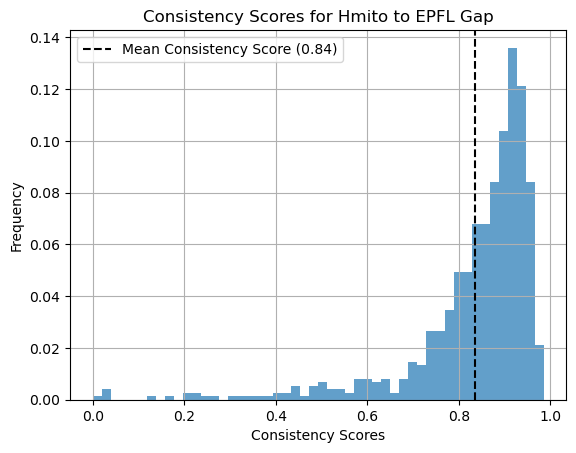

In [6]:
import matplotlib.pyplot as plt
import numpy as np
_ = plt.hist(1 - HtoE_DOa04_HD, bins=50, weights=np.ones(len(HtoE_DOa04_HD)) / len(HtoE_DOa04_HD), alpha=0.7)
plt.axvline(np.nanmean(1 - HtoE_DOa04_HD), linestyle='--', color='k', label=f'Mean Consistency Score ({np.nanmean(1 - HtoE_DOa04_HD):.2f})')
plt.grid()
plt.title("Consistency Scores for Hmito to EPFL Gap")
plt.xlabel('Consistency Scores')
plt.ylabel('Frequency')
plt.legend()
plt.show()